In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Now you're in R — load packages
install.packages(c("DBI", "RSQLite", "dplyr", "dbplyr", "tidyr", "readr",
                   "ggplot2", "corrplot", "cluster", "factoextra",
                   "lubridate", "scales", "stringr", "patchwork"),
                 repos = "http://cran.r-project.org", quiet = TRUE)

library(DBI); library(RSQLite); library(dplyr); library(dbplyr)
library(tidyr); library(readr); library(ggplot2); library(corrplot)
library(cluster); library(factoextra); library(lubridate)
library(scales); library(stringr); library(patchwork)

# Set path (Drive is already mounted by Python)
data_path <- "/content/drive/MyDrive/northstar_dataset1/output"

# Check files
list.files(data_path)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql


corrplot 0.95 loaded

Welcome to factoextra!

Want to learn more? See two factoextra-related 

[1] "clean_app_events_base.csv"      "clean_complaints_base.csv"     
 [3] "clean_complaints.csv"           "clean_customers_base.csv"      
 [5] "clean_data_dictionary_base.csv" "clean_deliveries_base.csv"     
 [7] "clean_deliveries.csv"           "clean_drivers_base.csv"        
 [9] "clean_hubs_base.csv"            "clean_incidents_base.csv"      
[11] "clean_incidents.csv"            "clean_orders_base.csv"         
[13] "clean_orders.csv"               "clean_vehicles_base.csv"       
[15] "northstar_clean.sqlite"         "plots"                         
[17] "reports"                        "zone_master_table.csv"

In [2]:
packages <- c("DBI", "RSQLite", "dplyr", "dbplyr", "tidyr", "readr",
              "ggplot2", "plotly", "corrplot", "cluster", "factoextra",
              "lubridate", "scales", "knitr", "kableExtra", "stringr",
              "patchwork")

install_if_missing <- function(pkg) {
  if (!require(pkg, character.only = TRUE, quietly = TRUE)) {
    install.packages(pkg, repos = "http://cran.r-project.org", quiet = TRUE)
    library(pkg, character.only = TRUE)
  }
}
invisible(sapply(packages, install_if_missing))


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


also installing the dependency ‘svglite’



Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




In [10]:
# For Google Colab with Drive mounted:
data_path <- "/content/drive/MyDrive/northstar_dataset1/output/"

# Map file names to table names (remove clean_ prefix, handle special cases)
file_map <- list(
  "incidents" = "clean_incidents.csv",
  "orders" = "clean_orders.csv",
  "customers" = "clean_customers_base.csv",
  "drivers" = "clean_drivers_base.csv",
  "zone" = "zone_master_table.csv",
  "hubs" = "clean_hubs_base.csv",
  "complaints" = "clean_complaints.csv",
  "vehicles" = "clean_vehicles_base.csv",
  "app_events" = "clean_app_events_base.csv",
  "deliveries" = "clean_deliveries.csv",
  "data_dictionary" = "clean_data_dictionary_base.csv"
)

# Create in-memory SQLite database for SQL operations
con <- dbConnect(RSQLite::SQLite(), ":memory:")

# Load each CSV into R environment AND into SQLite
for (tbl in names(file_map)) {
  file_path <- paste0(data_path, file_map[[tbl]])
  if (file.exists(file_path)) {
    df <- read_csv(file_path, show_col_types = FALSE)
    assign(tbl, df, envir = .GlobalEnv)
    dbWriteTable(con, tbl, df, overwrite = TRUE)
    cat("Loaded:", tbl, "from", file_map[[tbl]], "—", nrow(df), "rows,", ncol(df), "columns\n")
  } else {
    cat("WARNING: File not found —", file_path, "\n")
  }
}

# Verify tables in database
cat("\nTables in SQLite DB:", dbListTables(con), "\n\n")

Loaded: incidents from clean_incidents.csv — 280 rows, 9 columns
Loaded: orders from clean_orders.csv — 1250 rows, 13 columns
Loaded: customers from clean_customers_base.csv — 650 rows, 10 columns
Loaded: drivers from clean_drivers_base.csv — 170 rows, 9 columns
Loaded: zone from zone_master_table.csv — 103 rows, 4 columns
Loaded: hubs from clean_hubs_base.csv — 8 rows, 6 columns
Loaded: complaints from clean_complaints.csv — 320 rows, 14 columns
Loaded: vehicles from clean_vehicles_base.csv — 120 rows, 9 columns
Loaded: app_events from clean_app_events_base.csv — 640 rows, 11 columns
Loaded: deliveries from clean_deliveries.csv — 950 rows, 39 columns
Loaded: data_dictionary from clean_data_dictionary_base.csv — 9 rows, 3 columns

Tables in SQLite DB: app_events complaints customers data_dictionary deliveries drivers hubs incidents orders vehicles zone 



In [11]:
quick_profile <- function(df, name) {
  cat("\n===", name, "===\n")
  cat("Dimensions:", nrow(df), "x", ncol(df), "\n")
  cat("Columns:", paste(names(df), collapse = ", "), "\n")
  cat("Sample data:\n")
  print(head(df, 3))
}

# Profile all loaded tables
cat("\n--- DATA PROFILE ---\n")
for (tbl in dbListTables(con)) {
  df <- get(tbl)
  quick_profile(df, tbl)
}



--- DATA PROFILE ---

=== app_events ===
Dimensions: 640 x 11 
Columns: event_id, customer_id, order_id, event_timestamp, event_type, session_id, device_type, zone_context, api_latency_ms, success_flag, zone_context_standardized 
Sample data:
# A tibble: 3 × 11
  event_id customer_id order_id event_timestamp     event_type   session_id
  <chr>    <chr>       <chr>    <dttm>              <chr>        <chr>     
1 AE00001  C0488       O01227   2024-08-09 03:25:00 eta_refresh  S19847    
2 AE00002  C0595       O00950   2024-02-13 22:29:00 search_route S32766    
3 AE00003  C0494       O00170   2025-08-11 09:29:00 chat_opened  S99516    
# ℹ 5 more variables: device_type <chr>, zone_context <chr>,
#   api_latency_ms <dbl>, success_flag <dbl>, zone_context_standardized <chr>

=== complaints ===
Dimensions: 320 x 14 
Columns: complaint_id, customer_id, order_id, complaint_type, channel, severity, created_at, status, resolution_days, compensation_amount, complaint_delay_days, complaint_categ

Problems 1-2: Rising Complaints and Delays/Missing Windows

1.1 Monthly Deliveries Vs Complaints

In [14]:
library(DBI)
library(dplyr)
library(ggplot2)

qry_trend <- "
WITH d AS (
  SELECT
    substr(dispatch_time, 1, 7) AS month,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(is_unfulfilled) AS unfulfilled,
    SUM(late_delivery_flag) AS late
  FROM deliveries
  GROUP BY substr(dispatch_time, 1, 7)
),

c AS (
  SELECT
    substr(created_at, 1, 7) AS month,
    COUNT(*) AS complaints
  FROM complaints
  GROUP BY substr(created_at, 1, 7)
)

SELECT
  d.month,
  d.total_orders,
  d.unfulfilled,
  d.late,
  COALESCE(c.complaints, 0) AS complaints
FROM d
LEFT JOIN c
ON d.month = c.month
ORDER BY d.month;
"

trend_sql <- dbGetQuery(con, qry_trend)

trend_sql

month,total_orders,unfulfilled,late,complaints
<chr>,<int>,<dbl>,<dbl>,<int>
1704079,1,0,0,0
1704088,1,0,0,0
1704098,1,0,0,0
1704126,1,0,0,0
1704396,1,0,0,0
1704432,1,0,0,0
1704606,1,0,0,0
1704631,1,0,0,0
1704668,1,0,0,0


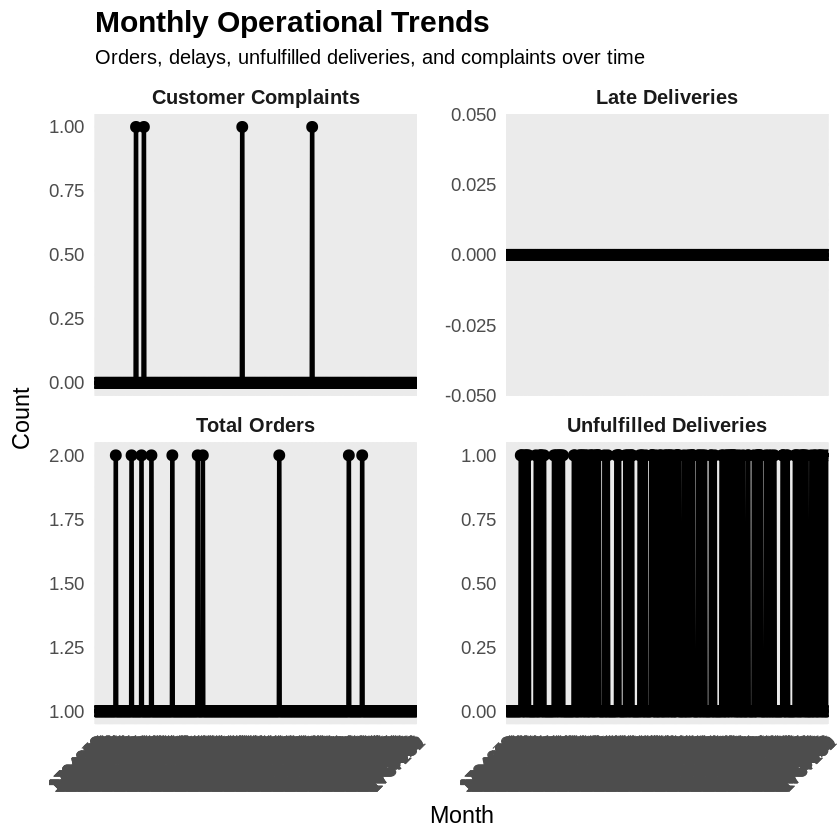

In [16]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)

# Reshape data
trend_long <- trend_sql %>%
  pivot_longer(
    cols = c(total_orders, unfulfilled, late, complaints),
    names_to = "metric",
    values_to = "value"
  ) %>%
  mutate(
    metric = recode(
      metric,
      total_orders = "Total Orders",
      unfulfilled = "Unfulfilled Deliveries",
      late = "Late Deliveries",
      complaints = "Customer Complaints"
    )
  )

# Faceted trend plot
ggplot(trend_long,
       aes(x = month, y = value, group = metric)) +

  geom_line(linewidth = 1.3) +
  geom_point(size = 2.5) +

  facet_wrap(~metric, scales = "free_y", ncol = 2) +

  scale_y_continuous(labels = comma) +

  labs(
    title = "Monthly Operational Trends",
    subtitle = "Orders, delays, unfulfilled deliveries, and complaints over time",
    x = "Month",
    y = "Count"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold", size = 12)
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


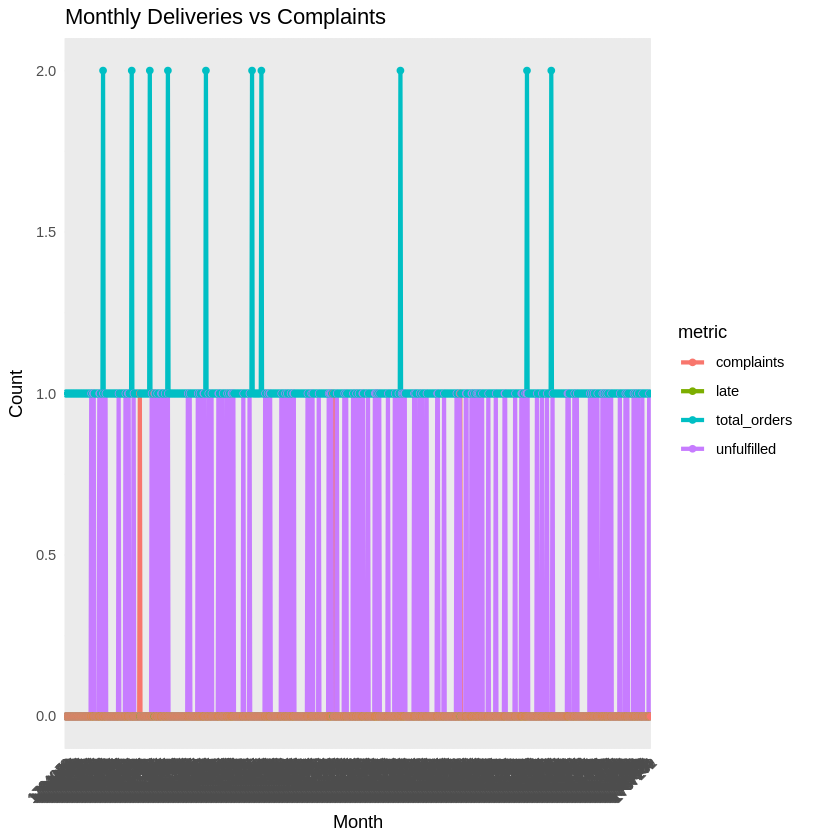

In [15]:
trend_long <- trend_sql %>%
  tidyr::pivot_longer(
    cols = c(total_orders, unfulfilled, late, complaints),
    names_to = "metric",
    values_to = "value"
  )

ggplot(trend_long,
       aes(x = month, y = value, color = metric, group = metric)) +
  geom_line(size = 1.2) +
  geom_point() +
  theme_minimal() +
  labs(
    title = "Monthly Deliveries vs Complaints",
    x = "Month",
    y = "Count"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Problem 3: Underperforming City Zones

2.1 Zone Performance query

In [18]:
qry_zone_perf <- "
SELECT
  h.zone_standardized AS zone,

  COUNT(DISTINCT d.order_id) AS total_orders,

  SUM(d.delivered_flag) AS delivered_orders,

  SUM(d.is_unfulfilled) AS unfulfilled_orders,

  ROUND(
    100.0 * SUM(d.is_unfulfilled) /
    COUNT(DISTINCT d.order_id), 2
  ) AS unfulfilled_pct,

  ROUND(AVG(d.delivery_time_hours), 2)
    AS avg_delivery_time_hours,

  ROUND(AVG(d.late_delivery_flag) * 100, 2)
    AS late_delivery_rate_pct,

  ROUND(AVG(d.delivery_time_outlier_flag) * 100, 2)
    AS anomaly_rate_pct

FROM deliveries d

LEFT JOIN hubs h
ON d.hub_id = h.hub_id

GROUP BY h.zone_standardized

ORDER BY unfulfilled_pct DESC,
         late_delivery_rate_pct DESC;
"

zone_perf_sql <- dbGetQuery(con, qry_zone_perf)

head(zone_perf_sql, 10)

,zone,total_orders,delivered_orders,unfulfilled_orders,unfulfilled_pct,avg_delivery_time_hours,late_delivery_rate_pct,anomaly_rate_pct
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>
1,Central Zone,243,194,49,20.16,NA,0,0
2,Airport,104,89,15,14.42,NA,0,0
3,West Zone,127,111,16,12.60,NA,0,0
4,North Zone,136,119,17,12.50,NA,0,0
5,Riverside,115,101,14,12.17,NA,0,0
6,South Zone,106,96,10,9.43,NA,0,0
7,East Zone,119,108,11,9.24,NA,0,0


Plot Worst Zones

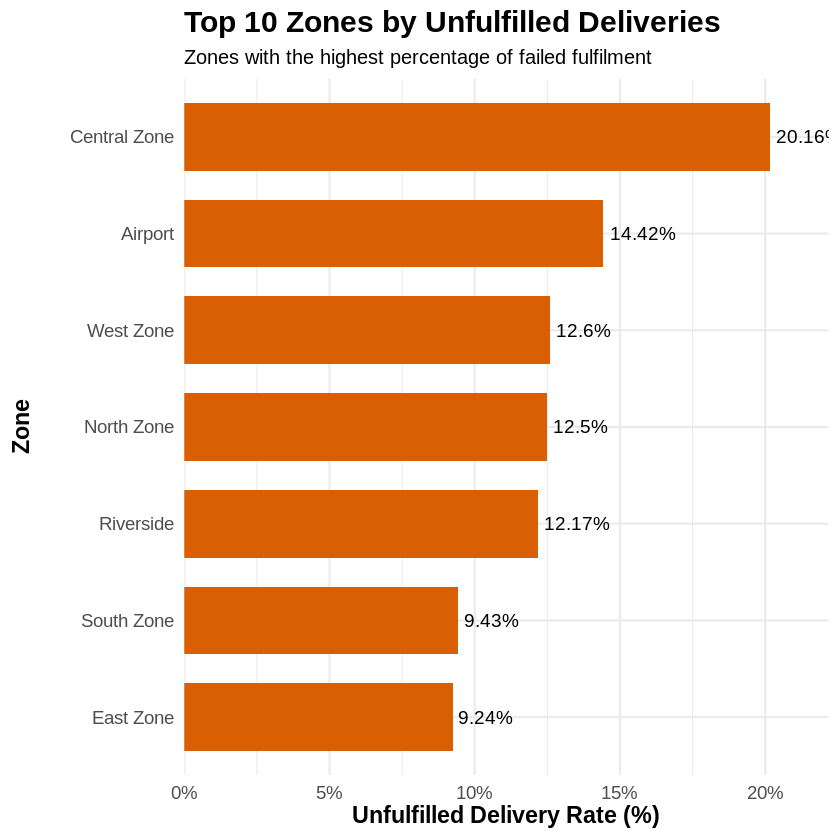

In [19]:
library(ggplot2)
library(scales)
library(dplyr)

worst_zones <- zone_perf_sql |>
  arrange(desc(unfulfilled_pct)) |>
  head(10)

ggplot(worst_zones,
       aes(x = reorder(zone, unfulfilled_pct),
           y = unfulfilled_pct)) +

  geom_col(fill = "#d95f02", width = 0.7) +

  geom_text(
    aes(label = paste0(unfulfilled_pct, "%")),
    hjust = -0.1,
    size = 4
  ) +

  coord_flip() +

  scale_y_continuous(
    labels = percent_format(scale = 1),
    expand = expansion(mult = c(0, 0.1))
  ) +

  labs(
    title = "Top 10 Zones by Unfulfilled Deliveries",
    subtitle = "Zones with the highest percentage of failed fulfilment",
    x = "Zone",
    y = "Unfulfilled Delivery Rate (%)"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 12),
    axis.title = element_text(face = "bold")
  )

Problem 1 & 9: Complaints By Cone and Service Type

3.1 Complaint Rate Per 100 Deliveries By Zone

In [20]:
qry_complaint_rate <- "

WITH delivery_counts AS (

    SELECT
        h.zone_standardized AS zone,
        COUNT(DISTINCT d.order_id) AS deliveries

    FROM deliveries d

    LEFT JOIN hubs h
    ON d.hub_id = h.hub_id

    GROUP BY h.zone_standardized
),

complaint_counts AS (

    SELECT
        o.pickup_zone_standardized AS zone,
        COUNT(*) AS complaints

    FROM complaints c

    LEFT JOIN orders o
    ON c.order_id = o.order_id

    GROUP BY o.pickup_zone_standardized
)

SELECT
    d.zone,
    d.deliveries,

    COALESCE(c.complaints, 0) AS complaints,

    ROUND(
        100.0 * COALESCE(c.complaints, 0) / d.deliveries,
        2
    ) AS complaints_per_100_deliveries

FROM delivery_counts d

LEFT JOIN complaint_counts c
ON d.zone = c.zone

ORDER BY complaints_per_100_deliveries DESC;
"

complaint_rate_zone <- dbGetQuery(con, qry_complaint_rate)

head(complaint_rate_zone, 10)

,zone,deliveries,complaints,complaints_per_100_deliveries
,<chr>,<int>,<int>,<dbl>
1,South Zone,106,46,43.40
2,East Zone,119,50,42.02
3,Riverside,115,45,39.13
4,North Zone,136,53,38.97
5,Airport,104,32,30.77
6,West Zone,127,34,26.77
7,Central Zone,243,42,17.28


3.2 Plot Complaint Rate

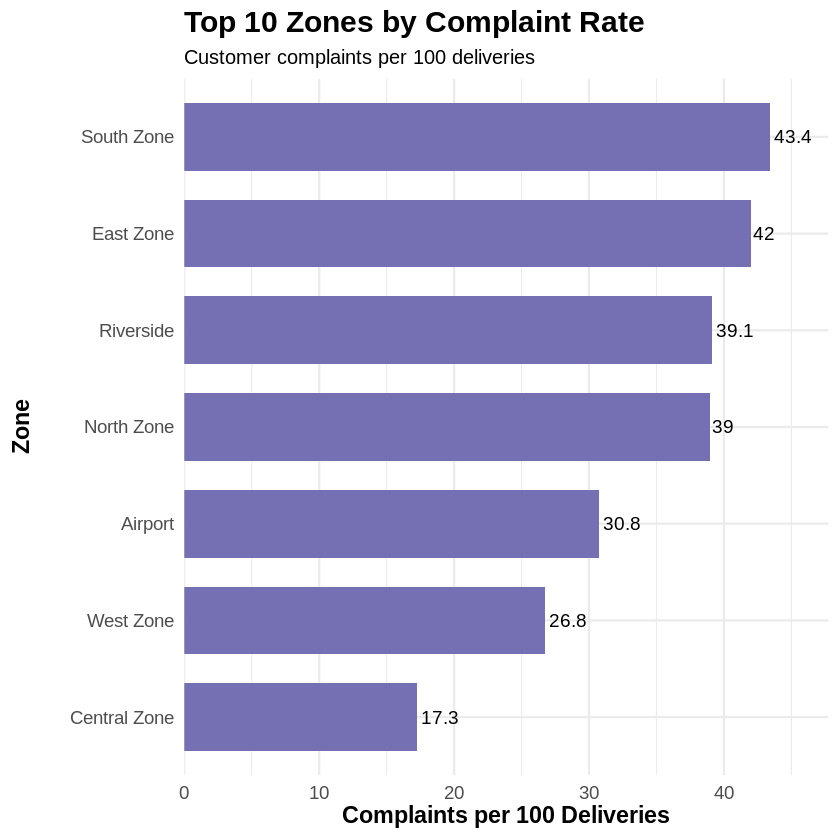

In [21]:
library(ggplot2)
library(scales)
library(dplyr)

top_complaint_zones <- complaint_rate_zone |>
  head(10)

ggplot(top_complaint_zones,
       aes(x = reorder(zone, complaints_per_100_deliveries),
           y = complaints_per_100_deliveries)) +

  geom_col(fill = "#7570b3", width = 0.7) +

  geom_text(
    aes(label = round(complaints_per_100_deliveries, 1)),
    hjust = -0.1,
    size = 4
  ) +

  coord_flip() +

  scale_y_continuous(
    expand = expansion(mult = c(0, 0.1))
  ) +

  labs(
    title = "Top 10 Zones by Complaint Rate",
    subtitle = "Customer complaints per 100 deliveries",
    x = "Zone",
    y = "Complaints per 100 Deliveries"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 12),
    axis.title = element_text(face = "bold")
  )

Problem 4 & 7: incidents, Downtime, and inconsistent Outcomes

4.1 Incident Serverty VS Delivery Outcome

In [22]:
qry_incident_outcomes <- "

SELECT
    i.incident_severity,

    d.is_unfulfilled,

    d.late_delivery_flag,

    COUNT(*) AS count

FROM incidents i

LEFT JOIN deliveries d
ON i.delivery_id = d.delivery_id

GROUP BY
    i.incident_severity,
    d.is_unfulfilled,
    d.late_delivery_flag

ORDER BY
    i.incident_severity,
    d.is_unfulfilled DESC,
    d.late_delivery_flag DESC;
"

incident_outcomes <- dbGetQuery(con, qry_incident_outcomes)

incident_outcomes

incident_severity,is_unfulfilled,late_delivery_flag,count
<chr>,<dbl>,<dbl>,<int>
Low,1,0,34
Low,0,0,246


4.2 orders with incidents but "Perfect" Flags

In [23]:
qry_inconsistent <- "

SELECT
    d.order_id,

    h.zone_standardized AS zone,

    d.is_unfulfilled,

    d.late_delivery_flag,

    d.delivered_flag,

    COUNT(i.incident_id) AS incident_count

FROM deliveries d

LEFT JOIN incidents i
ON d.delivery_id = i.delivery_id

LEFT JOIN hubs h
ON d.hub_id = h.hub_id

GROUP BY
    d.order_id,
    h.zone_standardized,
    d.is_unfulfilled,
    d.late_delivery_flag,
    d.delivered_flag

HAVING incident_count > 0
   AND is_unfulfilled = 0
   AND late_delivery_flag = 0
   AND delivered_flag = 1;
"

inconsistent_rows <- dbGetQuery(con, qry_inconsistent)

nrow(inconsistent_rows)

head(inconsistent_rows, 10)

[1] 219

,order_id,zone,is_unfulfilled,late_delivery_flag,delivered_flag,incident_count
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
1,O00009,North Zone,0,0,1,1
2,O00010,Central Zone,0,0,1,1
3,O00015,East Zone,0,0,1,2
4,O00017,South Zone,0,0,1,1
5,O00024,North Zone,0,0,1,1
6,O00042,North Zone,0,0,1,1
7,O00043,Airport,0,0,1,1
8,O00044,Riverside,0,0,1,1
9,O00052,Airport,0,0,1,2


Problems 3,4,11: Driver Performance and Incidents

Driver Risk Profile

In [24]:
qry_driver_risk <- "

WITH driver_inc AS (

  SELECT
      d.driver_id,
      COUNT(*) AS total_incidents,
      SUM(CASE WHEN i.incident_severity = 'High' THEN 1 ELSE 0 END)
        AS high_severity_incidents

  FROM incidents i

  LEFT JOIN deliveries d
  ON i.delivery_id = d.delivery_id

  GROUP BY d.driver_id
),

driver_del AS (

  SELECT
      driver_id,

      COUNT(DISTINCT order_id) AS total_deliveries,

      ROUND(AVG(delivery_time_hours), 2) AS avg_delivery_time_hours,

      ROUND(AVG(late_delivery_flag) * 100, 2) AS late_rate_pct,

      ROUND(AVG(delivery_time_outlier_flag) * 100, 2) AS anomaly_rate_pct,

      SUM(is_unfulfilled) AS unfulfilled_orders

  FROM deliveries

  GROUP BY driver_id
)

SELECT
    d.driver_id,
    d.total_deliveries,
    d.avg_delivery_time_hours,
    d.late_rate_pct,
    d.anomaly_rate_pct,
    d.unfulfilled_orders,

    COALESCE(i.total_incidents, 0) AS total_incidents,
    COALESCE(i.high_severity_incidents, 0) AS high_severity_incidents

FROM driver_del d

LEFT JOIN driver_inc i
ON d.driver_id = i.driver_id

ORDER BY
    d.late_rate_pct DESC,
    total_incidents DESC;
"

driver_risk <- dbGetQuery(con, qry_driver_risk)

head(driver_risk, 10)

,driver_id,total_deliveries,avg_delivery_time_hours,late_rate_pct,anomaly_rate_pct,unfulfilled_orders,total_incidents,high_severity_incidents
,<chr>,<int>,<lgl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,D039,9,NA,0,0,1,7,0
2,D087,12,NA,0,0,2,6,0
3,D004,9,NA,0,0,3,5,0
4,D026,11,NA,0,0,0,5,0
5,D132,4,NA,0,0,2,5,0
6,D146,8,NA,0,0,1,5,0
7,D002,7,NA,0,0,1,4,0
8,D032,4,NA,0,0,0,4,0
9,D037,8,NA,0,0,0,4,0


Problem 1 & 9: Complaint Types and Repeated Customers

In [26]:
qry_complaints_cat <- "

SELECT
    complaint_category_group,
    COUNT(*) AS complaint_count,
    ROUND(
        100.0 * COUNT(*) / (SELECT COUNT(*) FROM complaints),
        2
    ) AS complaint_pct
FROM complaints
GROUP BY complaint_category_group
ORDER BY complaint_count DESC;
"

complaints_cat <- dbGetQuery(con, qry_complaints_cat)

complaints_cat

complaint_category_group,complaint_count,complaint_pct
<chr>,<int>,<dbl>
Delay,101,31.56
Other,100,31.25
Platform / Tracking,53,16.56
Driver Behaviour,51,15.94
Damage,15,4.69
